# plot B cells related gene expression data
- related to Figure 3D, 3G & Fig S6 F, L

In [1]:
# load libraries
quiet_library <- function(...) {
    suppressPackageStartupMessages(library(...))
}
quiet_library("tidyverse")
quiet_library("ggplot2")
quiet_library("Matrix")
quiet_library("DESeq2")
quiet_library("dplyr")
quiet_library("SingleCellExperiment")
quiet_library("ggpubr")
quiet_library("knitr")
quiet_library("plotly")
quiet_library("scater")

Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘purrr’ was built under R version 4.4.3”
Warning message:
“package ‘lubridate’ was built under R version 4.4.2”
Warning message:
“package ‘Matrix’ was built under R version 4.4.3”
Warning message:
“package ‘DESeq2’ was built under R version 4.4.2”
Warning message:
“package ‘S4Vectors’ was built under R version 4.4.2”
Warning message:
“package ‘BiocGenerics’ was built under R version 4.4.2”
Warning message:
“package ‘IRanges’ was built under R version 4.4.2”
Warning message:
“package ‘GenomicRanges’ was built under R version 4.4.2”
Warning message:
“package ‘GenomeInfoDb’ was built under R version 4.4.2”
Warning message:
“package ‘SummarizedExperiment’ was built under R version 4.4.2”
Warning message:
“package ‘MatrixGenerics’ was built under R version 4.4.2”
Warning message:
“package ‘matrixStats’ was built under R version 4.4.2”
Warning message:
“package ‘Biobase’ was built under R version 4

In [2]:
# define the color palette to be used
npg_color <- c(
    "#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF",
    "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF"
)
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c(
    "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A",
    "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
    "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00"
)
ari_con_colors <- c("#4C8CBD", "#F59F00")
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
options(repr.plot.width = 20, repr.plot.height = 15)


In [3]:
# define working path
data_path <- "/home/workspace/data/ra_longitudinal/scrna/certPro"
output_path <- "/home/workspace/data/ra_longitudinal/output_results/certPro"
fig_path <- "/home/workspace/data/ra_longitudinal/figures/certPro"
proj_name <- "ALTRA_scRNA_AIFI_L3_Pseudobulk_certPro_"


In [4]:
# load helper functions
source("/home/workspace/github/ALTRA-manuscript/Analysis/scRNA/ALTRA_scRNA_R_helper_functions.r")

# loading the pseudobulk normalized data for plotting

In [5]:
# load pseudobulk gex data and deg result table
hise::cacheFiles(list('5e5886cc-454c-4e3c-b858-4bbb3701dfb8', 
                      '6bb60059-671e-4879-bff5-71b0c2060e1a'))

[1] "downloading fileID 5e5886cc-454c-4e3c-b858-4bbb3701dfb8"
[1] "downloading fileID 6bb60059-671e-4879-bff5-71b0c2060e1a"


[1] "/home/workspace/input/569004694/UCSDCU_Y4/5e5886cc-454c-4e3c-b858-4bbb3701dfb8/ALTRA_scRNA_AIFI_L3_Pseudobulk_certPro_AIM1_norm_counts_SE_list.rds"
[2] "/home/workspace/input/569004694/UCSDCU_Y4/6bb60059-671e-4879-bff5-71b0c2060e1a/ALTRA_scRNA_AIFI_L3_Pseudobulk_certPro_AIM1_BMI_deg_results.csv"

# plot specific gene expression in B cell subsets

In [6]:
# load normalized data
aim1_pb_norm <- readRDS(
    '/home/workspace/input/569004694/UCSDCU_Y4/5e5886cc-454c-4e3c-b858-4bbb3701dfb8/ALTRA_scRNA_AIFI_L3_Pseudobulk_certPro_AIM1_norm_counts_SE_list.rds'
)


In [13]:
## add status column with health and ARI
aim1_pb_norm <- lapply(aim1_pb_norm, function(pb) {
    # Modify disease category in coldata and convert to factor
    # Assuming 'status' is the column you want to modify
    pb$status <- factor(recode(pb$Status_Xsec, "ALTRA_healthy" = "HC1", "at_risk" = "ARI"), levels = c("HC1", "ARI"))
    return(pb)
})


In [14]:
# load the degs results
aim1_degs <- read_csv('/home/workspace/input/569004694/UCSDCU_Y4/6bb60059-671e-4879-bff5-71b0c2060e1a/ALTRA_scRNA_AIFI_L3_Pseudobulk_certPro_AIM1_BMI_deg_results.csv',
  show_col_types = FALSE
) %>%
  mutate(log_pval_dir = -log(pvalue) * sign(log2FoldChange))

## plot Fig 3D

In [15]:
# get naive deg results on IGHG3 genes
naive_degs_ighg3 <- aim1_degs %>% filter(cell_type == 'Core naive B cell' & str_detect(gene, "IGHG3"))


In [16]:
# get pseudobulk gene expression data
ighg3_exprs <- GetExprsSE(naive_degs_ighg3, aim1_pb_norm, assay = "normalized_counts")

In [17]:
ighg3_exprs%>% distinct(status)

status
<fct>
ARI
HC1


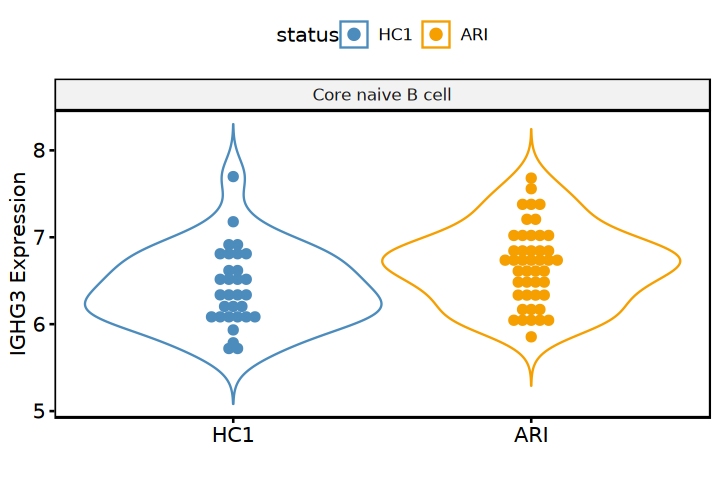

In [31]:
# plot the degs
options(repr.plot.width = 6, repr.plot.height = 4)
ighg3_exprs %>% ggpubr::ggviolin(
    x = "status", add = c("dotplot"),
    ylab = "IGHG3 Expression", xlab = "",
    y = "normalized_counts", palette = ari_con_colors,
    color = "status", facet.by = "cell_type",
    add.params = list(binwidth = 1 / 10)
)
# ggsave(file.path(fig_path, paste0(proj_name, "IGHG3_expression_violinplot.pdf")), width = 6, height = 4)


## plot Fig S6F

In [24]:
# get naive deg results on IGHM genes
naive_degs_ighm <- aim1_degs %>% filter(cell_type == 'Core naive B cell' & str_detect(gene, "IGHM"))
naive_degs_ighm

cell_type,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,q_values,sig,log_pval_dir
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
Core naive B cell,IGHM,8688.049,0.08665611,0.0358827,2.414983,0.01573593,0.08823524,0.04653676,*,4.151808


In [25]:
# get pseudobulk gene expression data
ighm_exprs <- GetExprsSE(naive_degs_ighm, aim1_pb_norm, assay = "normalized_counts")

Bin width defaults to 1/30 of the range of the data. Pick better value with
`binwidth`.


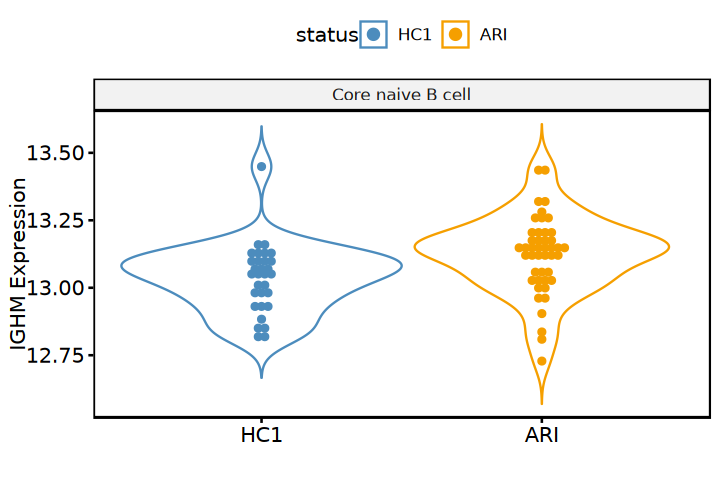

In [32]:
# plot the degs
options(repr.plot.width = 6, repr.plot.height = 4)
ighm_exprs %>% ggpubr::ggviolin(
    x = "status", add = c("dotplot"),
    ylab = "IGHM Expression", xlab = "",
    y = "normalized_counts", palette = ari_con_colors,
    color = "status", facet.by = "cell_type"
)
# ggsave(file.path(fig_path, paste0(proj_name, "IGHM_expression_violinplot.pdf")), width = 6, height = 4)


## plot Fig S6L

In [33]:
# get naive deg results on IGHM genes
naive_degs_pax5 <- aim1_degs %>% filter(cell_type == 'Core naive B cell' & str_detect(gene, "PAX5"))
naive_degs_pax5

cell_type,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,q_values,sig,log_pval_dir
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
Core naive B cell,PAX5,335.3438,-0.1336125,0.05354083,-2.495525,0.01257708,0.07757783,0.04091586,*,-4.375879


In [34]:
# get pseudobulk gene expression data
pax5_exprs <- GetExprsSE(naive_degs_pax5, aim1_pb_norm, assay = "normalized_counts")

Bin width defaults to 1/30 of the range of the data. Pick better value with
`binwidth`.


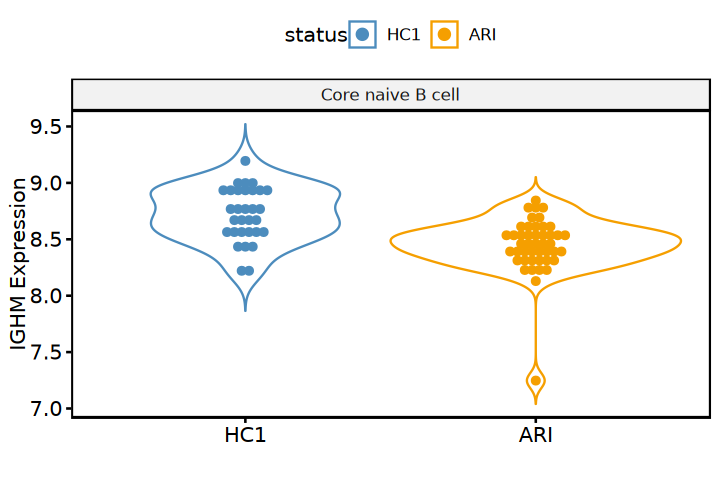

In [35]:
# plot the degs
options(repr.plot.width = 6, repr.plot.height = 4)
pax5_exprs %>% ggpubr::ggviolin(
    x = "status", add = c("dotplot"),
    ylab = "IGHM Expression", xlab = "",
    y = "normalized_counts", palette = ari_con_colors,
    color = "status", facet.by = "cell_type"
)
# ggsave(file.path(fig_path, paste0(proj_name, "IGHM_expression_violinplot.pdf")), width = 6, height = 4)


# plot specific pathways for B naive

In [23]:
quiet_library("fgsea")

In [71]:
# define a function to run gsea 
RankGene <- function(logfc_list, gmx = NULL, ct.col = "cell_type",
                     rank.col = "logfc", gene.col = "gene",
                     collapsePathways = FALSE,
                     ncores = NULL) {
  require(fgsea)
  # if no provided, Load and initialize pathway database
  if (is.null(gmx)) {
    gmxFile <- "/home/workspace/data/reference/c2.cp.v7.2.symbols.gmt"
    colNames <- max(count.fields(file = gmxFile, sep = "\t"))
    colNames <- seq(from = 1, to = colNames)
    colNames <- as.character(colNames)
    gmx <- read.table(
      file = gmxFile,
      sep = "\t",
      quote = "\"",
      fill = TRUE,
      col.names = colNames,
      row.names = 1
    )
    gmx <- gmx[, -1]
    gmx <- apply(gmx, MARGIN = 1, FUN = function(x) {
      return(value = setdiff(unname(x), ""))
    })
    names(gmx) <- toupper(names(gmx))
  }

  # setup parallelization parameters
  if (is.null(ncores)) {
    ncores <- parallel::detectCores() - 3
  } else {
    (ncores <- ncores)
  }
  param <- BiocParallel::MulticoreParam(workers = ncores, progressbar = TRUE)

  # RUN GSEA per celltype
  celltypes <- unique(logfc_list %>% pull(.data[[ct.col]]))
  # create rank list based on lowest to higest gene fold-change
  rnkDF <- logfc_list %>%
    filter(!is.na(.data[[rank.col]])) %>%
    dplyr::arrange(.data[[rank.col]])
  rnk <- rnkDF %>%
    pull(.data[[rank.col]]) %>%
    as.numeric()
  names(rnk) <- rnkDF %>% pull(.data[[gene.col]])

  return(rnkDF)
}


In [72]:
Bna_aim1_deg <- aim1_degs %>% filter(cell_type == "Core naive B cell")
rank.col <- "log_pval_dir"
gene.col <- "gene"
Bna_aim1_rank <- Bna_aim1_deg %>%
      filter(!is.na(.data[[rank.col]])) %>%
      dplyr::arrange(.data[[rank.col]])
Bna_rank <- Bna_aim1_rank %>%
      pull(.data[[rank.col]]) %>%
      as.numeric()
names(Bna_rank) <- Bna_aim1_rank %>% pull(.data[[gene.col]])
# Bna_rank


In [73]:
# get pathway database
gmxFile <- "/home/workspace/github/ALTRA-manuscript/Analysis/scRNA/c2.cp.v7.2.symbols.gmt"
colNames <- max(count.fields(file = gmxFile, sep = "\t"))
colNames <- seq(from = 1, to = colNames)
colNames <- as.character(colNames)
gmx <- read.table(
  file = gmxFile,
  sep = "\t",
  quote = "\"",
  fill = TRUE,
  col.names = colNames,
  row.names = 1
)
gmx <- gmx[, -1]
gmx <- apply(gmx, MARGIN = 1, FUN = function(x) {
  return(value = setdiff(unname(x), ""))
})
names(gmx) <- toupper(names(gmx))


In [75]:
# run GSEA by parallelization
param <- BiocParallel::MulticoreParam(workers = 15, progressbar = TRUE)
fgseaRes <- fgsea::fgsea(
    pathways = gmx,
    stats = Bna_rank,
    minSize = 10,
    maxSize = 500, nPermSimple = 10000,
    BPPARAM = param
)


  |======================================================================| 100%



In [78]:
# define a function to plot pathway enrichment
PlotPathway <- function(pathwayName, gmx, gene_list) {
  enrichmentPlot <- plotEnrichment(
    gmx[[pathwayName]],
    gene_list
  )
  data <- ggplot_build(enrichmentPlot)$data

  pathwayNameFormatted <- gsub("_", " ", pathwayName)
  # Create plot
  customPlot <- ggplot() +
    geom_line(data = data[[1]], aes(x = x, y = y), color = "purple") +
    geom_segment(data = data[[1]], aes(x = x, xend = x, y = -0.1, yend = 0), color = "black", size = 0.5) +
    ggtitle(pathwayNameFormatted) +
    labs(
      x = "Ranked Genes",
      y = "Enrichment Score",
      # caption = "ARI \u27F5\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u27F6 Control"
    ) +
    theme_minimal() +
    theme(
      plot.title = element_text(hjust = 0.5), # Center the title
      plot.caption = element_text(hjust = 0.5, vjust = -0.5, size = 12.5),
      plot.margin = margin(t = 10, r = 10, b = 40, l = 10) # Add space below the plot
    )
  return(customPlot)
}


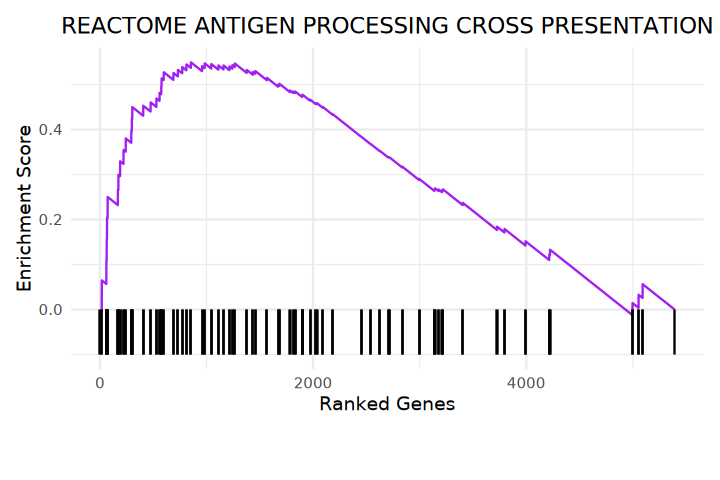

In [219]:
p1 <- PlotPathway(
       "REACTOME_ANTIGEN_PROCESSING_CROSS_PRESENTATION", gmx,
       Bna_rank
)
p1
ggsave(file.path(fig_path, "AIM1_Bnaive_gseaplot_REACTOME_ANTIGEN_PROCESSING_CROSS_PRESENTATION.png"),
       width = 4, height = 4
)


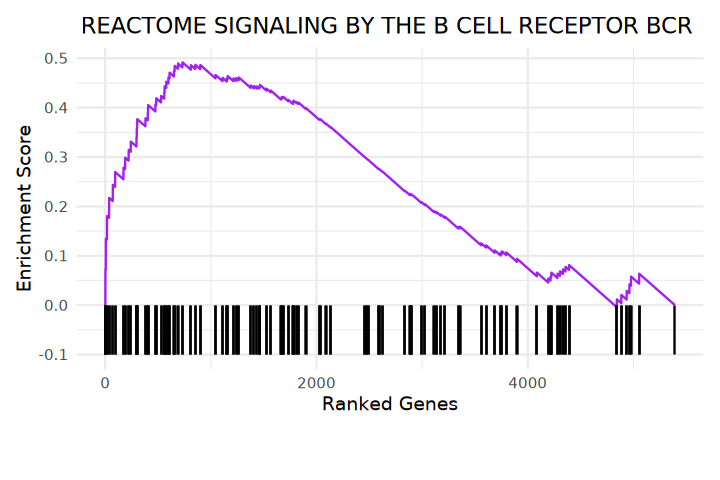

In [220]:
p1 <- PlotPathway(
       "REACTOME_SIGNALING_BY_THE_B_CELL_RECEPTOR_BCR_", gmx,
       Bna_rank
)
p1

ggsave(file.path(fig_path, "AIM1_Bnaive_gseaplot_BCR.png"),
       width = 4, height = 4
)


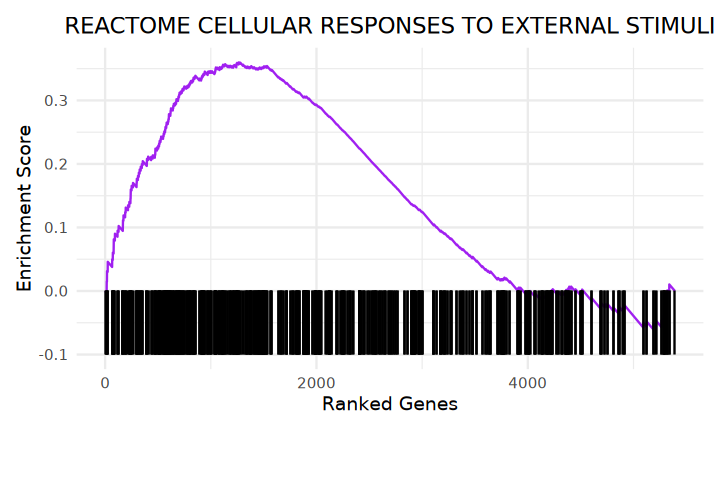

In [221]:
p1 <- PlotPathway(
       "REACTOME_CELLULAR_RESPONSES_TO_EXTERNAL_STIMULI", gmx,
       Bna_rank
)
p1
ggsave(file.path(fig_path, "AIM1_Bnaive_gseaplot_REACTOME_CELLULAR_RESPONSES_TO_EXTERNAL_STIMULI.png"),
       width = 4, height = 4
)


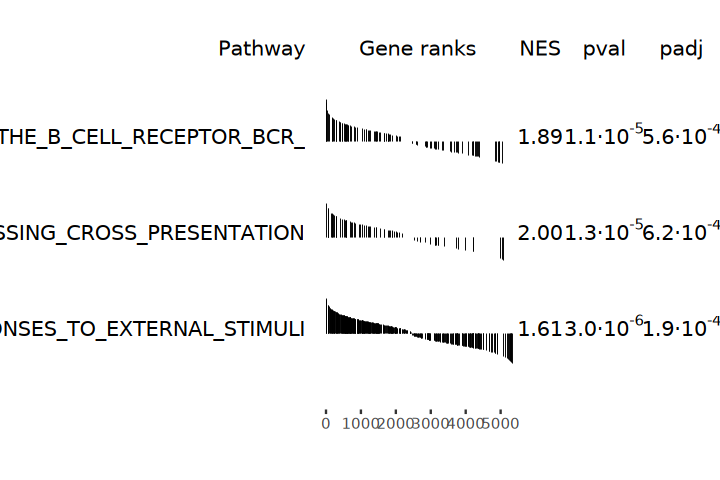

In [222]:
topPathways <- c(
       "REACTOME_SIGNALING_BY_THE_B_CELL_RECEPTOR_BCR_",
       "REACTOME_ANTIGEN_PROCESSING_CROSS_PRESENTATION",
       "REACTOME_CELLULAR_RESPONSES_TO_EXTERNAL_STIMULI"
)

plotGseaTable(gmx[topPathways], Bna_rank, fgseaRes,
       gseaParam = 0.5
)
ggsave(file.path(fig_path, "AIM1_Bnaive_gseaplot_combined_pathway.png"),
       width = 6, height = 4
)


## plot Fig 3G

In [203]:
# define a function to plot pathway enrichment
PlotPathways <- function(pathways, gmx, gene_list) {
  pathway_data <- lapply(pathways, function(pathwayName) {
    gene_list <- Bna_rank
    enrichmentPlot <- plotEnrichment(
      gmx[[pathwayName]],
      gene_list
    )
    data <- ggplot_build(enrichmentPlot)$data[[1]] %>%
      as_tibble() %>%
      mutate(pathway = gsub("_", " ", pathwayName))
    return(data)
  }) %>% data.table::rbindlist()

  # Create plot
  p1 <- ggplot(pathway_data) +
    geom_line(aes(x = x, y = y, color = pathway)) +
    #  geom_segment(aes(x = x, color = pathway, xend = x, y = -0.1, yend = 0), size = 0.5) +
    # facet_wrap(vars(pathway)) +
    labs(
      x = "Ranked Genes",
      y = "Enrichment Score",
      # caption = "ARI \u27F5\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u27F6 Control"
    ) +
    theme_pubr() +
    theme(
      plot.title = element_text(hjust = 0.5), # Center the title
      plot.caption = element_text(hjust = 0.5, vjust = -0.5, size = 12.5),
      legend.position = c(1.2, 0.8), # Move legend inside the plot
      # legend.background = element_rect(fill = "white", color = "black")
    ) +
    scale_color_manual(values = npg_color)
  p2 <- ggplot(pathway_data) +
    geom_segment(aes(
      x = x, color = pathway, group = pathway,
      xend = x, y = -0.1, yend = 0
    ), size = 0.5) +
    facet_grid(vars(rows = pathway)) +
    theme_void() +
    ylab("") +
    xlab("") +
    theme(
      plot.title = element_text(hjust = 0.5), # Center the title
      plot.caption = element_text(hjust = 0.5, vjust = -0.5, size = 12.5),
      axis.text.y = element_blank(),
      axis.ticks.y = element_blank(), axis.text.x = element_blank(),
      axis.ticks.x = element_blank(),
      strip.text.y = element_blank(),
      legend.position = "none"
    ) +
    scale_color_manual(values = npg_color)
  p_comb <- ggarrange(p1, p2,
    ncol = 1, # common.legend = TRUE, legend="right",
    heights = c(2, 1)
  )
  return(p_comb)
}


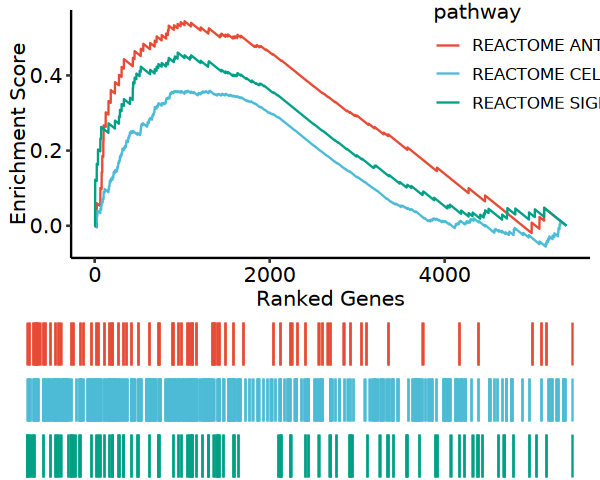

In [204]:
topPathways <- c(
       "REACTOME_SIGNALING_BY_THE_B_CELL_RECEPTOR_BCR_",
       "REACTOME_ANTIGEN_PROCESSING_CROSS_PRESENTATION",
       "REACTOME_CELLULAR_RESPONSES_TO_EXTERNAL_STIMULI"
)
options(repr.plot.width = 5, repr.plot.height = 4)
p1 <- PlotPathways(
       topPathways, gmx,
       Bna_rank
)
p1
ggsave(file.path(fig_path, "AIM1_Bnaive_gseaplot_combined_pathway.pdf"),
       width = 5, height = 4
)


In [191]:
library("genekitr")



Welcome to use genekitr! (Vignette: https://www.genekitr.fun)
Citation for genekitr:
Liu, Y., Li, G. Empowering biologists to decode omics data: the Genekitr R package and web server. BMC Bioinformatics 24, 214 (2023). https://doi.org/10.1186/s12859-023-05342-9



In [199]:
# 3rd step: GSEA analysis
gs <- geneset::getReactome(org = "human")
gse <- genGSEA(genelist = sort(Bna_rank, decreasing = TRUE), geneset = gs)

In [201]:
gse$gsea_df %>% filter(p.adjust < 0.05 & str_detect(Description, "BCR|Antigen"))


,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,geneID,Count
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<int>
R-HSA-1236975,R-HSA-1236975,Antigen processing-Cross presentation,72,0.5506736,2.005974,2.587085e-05,0.0004991946,0.0003837373,1262,"tags=47%, list=24%, signal=36%",9491/3106/8773/653361/5691/1535/5693/7979/8673/5692/10952/5701/695/5688/5683/5720/5710/23480/5690/5707/5689/7314/5704/3133/5706/6233/6891/9554/5685/5686/5698/5708/5702/9861/7311,35
R-HSA-983705,R-HSA-983705,Signaling by the B Cell Receptor (BCR),96,0.4701640,1.800559,1.206128e-04,0.0015713162,0.0012078909,730,"tags=26%, list=14%, signal=23%",930/973/9491/84876/5691/2280/5693/7979/5692/5777/5701/695/5532/5688/5683/974/5720/5710/5690/5707/5689/6500/8454/29760/7314/5704,26
R-HSA-1168372,R-HSA-1168372,Downstream signaling events of B Cell Receptor (BCR),69,0.4588419,1.660790,2.705512e-03,0.0183349367,0.0140943010,1466,"tags=49%, list=27%, signal=36%",9491/5691/2280/5693/7979/5692/5701/5532/5688/5683/5720/5710/5690/5707/5689/6500/8454/7314/5704/5706/6233/5685/5686/8915/5698/5708/5702/9861/7311/10213/4772/5709/84433/5478/808,35
